In [1]:
# =============================================================================
# URBAN QUALITY OF LIFE INDEX — MARSEILLE DISTRICTS
# =============================================================================
# Computes a composite quality-of-life index for each of the 16 arrondissements
# of Marseille using OpenStreetMap data (via OSMnx).
# Each district is characterized by 10 urban indicators (densities / coverages),
# normalized and aggregated into a single weighted index.
# =============================================================================

In [2]:
# --- Imports -----------------------------------------------------------------

import geopandas as gpd
import shapely
import pandas as pd
import osmnx as ox
from sklearn.preprocessing import MinMaxScaler
import session_info
import overpy
import matplotlib.pyplot as plt
import os
import contextily as ctx
from collections import Counter
import re
import h3pandas
import h3
import leafmap

In [3]:
# =============================================================================
# STEP 1 — DATA COLLECTION
# =============================================================================

In [4]:
def get_place_profile(place):
    
    """
    Downloads and saves OpenStreetMap features for a given place (district).
 
    For each thematic category (transport, green spaces, health, education,
    safety, commerce), OSM features are queried and saved as GeoJSON files
    in a dedicated folder under data/<place>/.
 
    Parameters
    ----------
    place : str
        Name of the district as recognized by OSM geocoder
        (e.g. '1er arrondissement, Marseille').
    """
    
    # Create output folder for this district if it does not exist
        
    folderout = 'data/' + place
    if not os.path.exists(folderout):
        os.makedirs(folderout)
        
        
    # --- Transport ---
    # Download the full road network (all types) and public transport features
    
    roads = ox.graph_from_place(place, network_type='all')
    public_transport = ox.features_from_place(place, tags={'public_transport':True}) 
    ox.save_graphml(roads, filepath = folderout + '/roads.graphml')
    public_transport.to_file(folderout + '/public_transport.geojson', driver='GeoJSON')
    
    # --- Green spaces ---
    
    parks = ox.features_from_place(place, tags={'leisure':'park'})
    recreation = ox.features_from_place(place, tags={'leisure':['recreation_ground', 'pitch']})  
    parks.to_file(folderout + '/parks.geojson', driver='GeoJSON')
    recreation.to_file(folderout + '/recreation.geojson', driver='GeoJSON')
    
    # --- Health & Education ---
    
    healthcare = ox.features_from_place(place, tags={'amenity':['hospital', 'pharmacy']})
    education = ox.features_from_place(place, tags={'amenity':['school', 'university']})    
    healthcare.to_file(folderout + '/healthcare.geojson', driver='GeoJSON')
    education.to_file(folderout + '/education.geojson', driver='GeoJSON')
    
     # --- Safety & Lighting ---
        
    emergency_services = ox.features_from_place(place, tags={'amenity':['police', 'fire_station', 'clinic']})
    street_light = ox.features_from_place(place, tags={'highway':['street_lamp']})
    emergency_services.to_file(folderout + '/emergency_services.geojson', driver='GeoJSON')
    street_light.to_file(folderout + '/street_light.geojson', driver='GeoJSON')
    
    # --- Economy ---
    
    commerce = ox.features_from_place(place, tags={'shop': True})
    employment_centers = ox.features_from_place(place, tags={'office': True, 'industrial': True})
    commerce.to_file(folderout + '/commerce.geojson', driver='GeoJSON')
    employment_centers.to_file(folderout + '/employment_centers.geojson', driver='GeoJSON')

In [5]:
# --- Run data collection for all 16 Marseille districts ---------------------

In [6]:
# Build district name list: '1er', '2e', ..., '16e'
district_numbers = [f"{i}{'er' if i < 2 else 'e'}" for i in range(1, 17)]

for dn in district_numbers:
    place = dn + ' arrondissement, Marseille'
     # Geocode the district boundary and save it as a GeoJSON polygon
    admin_d = ox.geocode_to_gdf(place)
    get_place_profile(place)
    admin_d.to_file('data/' + place + '/admin_boundaries.geojson', driver='GeoJSON')

In [7]:
# =============================================================================
# STEP 2 — DISTRICT CHARACTERIZATION
# =============================================================================

In [8]:
def characterize_district(place) :
    
    """
    Computes 10 urban indicators for a given district from saved GeoJSON files.
 
    All indicators are expressed as densities (count or area per km²),
    allowing fair comparison between districts of different sizes.
 
    Parameters
    ----------
    place : str
        Name of the district (must match the folder name under data/).
 
    Returns
    -------
    pd.DataFrame
        Single-row DataFrame containing the 10 computed indicators.
    """

    folderin = 'data/' + place
    
    # Load all previously saved spatial datasets
    roads_graph = ox.load_graphml(folderin + '/roads.graphml')
    parks = gpd.read_file(folderin + '/parks.geojson')
    recreation = gpd.read_file(folderin + '/recreation.geojson')
    public_transport = gpd.read_file(folderin + '/public_transport.geojson')
    healthcare = gpd.read_file(folderin + '/healthcare.geojson')
    education = gpd.read_file(folderin + '/education.geojson')
    emergency_services = gpd.read_file(folderin + '/emergency_services.geojson')
    street_lighting = gpd.read_file(folderin + '/street_light.geojson')
    commerce = gpd.read_file(folderin + '/commerce.geojson')
    employment_centers = gpd.read_file(folderin + '/employment_centers.geojson')
    
    # Use RGF93 / Lambert-93 (EPSG:2154) for accurate metric area computation in France
    crs = 2154
    
     # Extract road edges from the graph and compute total road length (km)
    edges = ox.graph_to_gdfs(roads_graph, nodes=False, edges=True)
    road_length = edges['length'].sum() / 1000
    
    # Estimate district area (km²) using the convex hull of the road network extent
    # Note: convex hull is an approximation — actual admin boundary would be more precise
    total_area = edges.to_crs(crs).union_all().convex_hull.area/1000**2
    
    # --- Compute indicators (normalized by district area) ---
    road_density = road_length/total_area  # km of road per km²
    public_transport_density = len(public_transport) / total_area # stops per km²
    
    park_coverage = (parks.to_crs(crs).area.sum()) / 1000**2 / total_area  # ratio [0-1]
    recreation_density = len(recreation) / total_area  # features per km²
    
    healthcare_accesibility = len(healthcare) / total_area # facilities per km²
    education_accessibility = len(education) / total_area # facilities per km²
    
    emergency_services_density = len(emergency_services) / total_area  # facilities per km²
    street_lighting_density = len(street_lighting) / total_area  # lamps per km²
    
    commerce_density = len(commerce) / total_area  # shops per km²
    employment_centers_density = len(employment_centers) / total_area  # offices per km²

    # Compile all indicators into a dictionary and return as a DataFrame row
    data = {
        'place' : place,
        'Road Density' : road_density,
        'Public Transport Density' : public_transport_density,
        'Park Coverage' : park_coverage,
        'Recreation Density' : recreation_density,
        'Healthcare Accesibility' : healthcare_accesibility,
        'Education Accessibility' : education_accessibility,
        'Emergency Services Density' : emergency_services_density,
        'Street Lighting Density' : street_lighting_density,
        'Commerce Density' : commerce_density,
        'Employment Centers Density' : employment_centers_density
    }
    
    df = pd.DataFrame([data]) 
    
    return df

In [9]:
# --- Run characterization for all districts and concatenate results ----------
districts = [f for f in os.listdir('data') if '.' not in f]

df_all = []

for district in districts :
    df = characterize_district(district)
    print(district, len(df))
    df_all.append(df)

# Concatenate all district rows into a single DataFrame indexed by district name
df_all = pd.concat(df_all).set_index('place')

10e arrondissement, Marseille 1
11e arrondissement, Marseille 1
12e arrondissement, Marseille 1
13e arrondissement, Marseille 1
14e arrondissement, Marseille 1
15e arrondissement, Marseille 1
16e arrondissement, Marseille 1
1er arrondissement, Marseille 1
2e arrondissement, Marseille 1
3e arrondissement, Marseille 1
4e arrondissement, Marseille 1
5e arrondissement, Marseille 1
6e arrondissement, Marseille 1
7e arrondissement, Marseille 1
8e arrondissement, Marseille 1
9e arrondissement, Marseille 1


In [10]:
# --- Correlation matrix — exploratory check ---------------------------------
# High correlations between indicators may suggest redundancy
# (e.g. healthcare and commerce density are strongly correlated at ~0.96)

df_all.corr()

,Road Density,Public Transport Density,Park Coverage,Recreation Density,Healthcare Accesibility,Education Accessibility,Emergency Services Density,Street Lighting Density,Commerce Density,Employment Centers Density
Road Density,1.000000,0.808381,-0.145895,0.330144,0.818259,0.823556,0.747892,0.220458,0.689039,0.684635
Public Transport Density,0.808381,1.000000,-0.113130,0.325924,0.957415,0.805846,0.907877,0.124114,0.871587,0.841751
Park Coverage,-0.145895,-0.113130,1.000000,0.391585,-0.148316,0.001990,-0.012002,0.235076,-0.200425,-0.171008
Recreation Density,0.330144,0.325924,0.391585,1.000000,0.138308,0.301644,0.516410,0.500588,-0.027927,-0.013202
Healthcare Accesibility,0.818259,0.957415,-0.148316,0.138308,1.000000,0.810240,0.807643,-0.028842,0.960355,0.933867
Education Accessibility,0.823556,0.805846,0.001990,0.301644,0.810240,1.000000,0.818100,0.148699,0.678432,0.766059
Emergency Services Density,0.747892,0.907877,-0.012002,0.516410,0.807643,0.818100,1.000000,0.198516,0.655109,0.680902
Street Lighting Density,0.220458,0.124114,0.235076,0.500588,-0.028842,0.148699,0.198516,1.000000,-0.152045,-0.157955
Commerce Density,0.689039,0.871587,-0.200425,-0.027927,0.960355,0.678432,0.655109,-0.152045,1.000000,0.968853
Employment Centers Density,0.684635,0.841751,-0.171008,-0.013202,0.933867,0.766059,0.680902,-0.157955,0.968853,1.000000


In [11]:
# =============================================================================
# STEP 3 — INDEX COMPUTATION
# =============================================================================

In [12]:
df = df_all.copy()

In [13]:
# --- Load administrative boundaries for all districts -----------------------
gdf_admin = []

for district in os.listdir('data'):
    if '.DS' not in district: # Exclude macOS system files
        gdf = gpd.read_file('data/' + district + '/admin_boundaries.geojson')
        gdf['place'] = district
        gdf_admin.append(gdf)

gdf_admin = pd.concat(gdf_admin)

In [14]:
# --- Normalize all indicators to a [1, 10] scale ----------------------------
# MinMaxScaler rescales each column independently to the specified range

scaler = MinMaxScaler(feature_range=(1,10))

df_normalized = pd.DataFrame(
    scaler.fit_transform(df),
    columns = df.columns,
    index = df.index
)

df_normalized.head()

,Road Density,Public Transport Density,Park Coverage,Recreation Density,Healthcare Accesibility,Education Accessibility,Emergency Services Density,Street Lighting Density,Commerce Density,Employment Centers Density
place,,,,,,,,,,
"10e arrondissement, Marseille",6.069110,2.459347,3.327577,5.872243,1.847438,2.441228,1.537736,4.409110,1.450228,1.423267
"11e arrondissement, Marseille",1.584033,1.337782,1.593206,1.700278,1.080670,1.185069,1.069930,2.643545,1.086585,1.000000
"12e arrondissement, Marseille",3.837620,2.890889,2.554270,5.967666,1.866233,2.277499,2.836612,7.791298,1.252371,1.145582
"13e arrondissement, Marseille",2.948608,1.989079,2.696977,3.411845,1.387285,1.999642,1.686453,3.388666,1.022124,1.041542
"14e arrondissement, Marseille",3.692564,2.428275,2.996131,4.443428,1.521288,2.225422,1.862397,3.814430,1.101428,1.141722


In [15]:
# --- Define indicator weights -----------------------------------------------
# Weights reflect the relative importance of each dimension in the final index.
# Public transport and commerce are weighted higher (0.15) as key urban drivers.
# All weights must sum to 1.0.

weights = {
    'Road Density': 0.1,
    'Public Transport Density': 0.15,
    'Park Coverage': 0.1,
    'Recreation Density': 0.1,
    'Healthcare Accesibility': 0.1,
    'Education Accessibility': 0.1,
    'Emergency Services Density': 0.1,
    'Street Lighting Density': 0.1,
    'Commerce Density': 0.15,
    'Employment Centers Density': 0.1
}

In [16]:
# Apply weights: multiply each indicator column by its corresponding weight

for feature in df_normalized.columns:
    df_normalized[feature] = df_normalized[feature] * weights[feature]

In [17]:
# Compute the Unified Index as the weighted sum of all indicators

df_normalized['Unified Index'] = df_normalized.sum(axis=1)

df_normalized[['Unified Index']]

,Unified Index
place,
"10e arrondissement, Marseille",3.279207
"11e arrondissement, Marseille",1.549328
"12e arrondissement, Marseille",3.449167
"13e arrondissement, Marseille",2.307782
"14e arrondissement, Marseille",2.699194
"15e arrondissement, Marseille",3.290868
"16e arrondissement, Marseille",1.874189
"1er arrondissement, Marseille",7.836640
"2e arrondissement, Marseille",2.287834


In [18]:
# Re-normalize the Unified Index to [1, 10] for readability and round to integer

scaler = MinMaxScaler(feature_range=(1,10))

df_normalized['Unified Index'] = scaler.fit_transform(df_normalized[['Unified Index']])

df_normalized['Unified Index'] = df_normalized['Unified Index'].round(0)

In [19]:
# =============================================================================
# STEP 4 — VISUALIZATION
# =============================================================================

In [20]:
# --- Merge index with administrative boundaries for mapping -----------------

gdf_index = gdf_admin[['place', 'geometry']].merge(df_normalized[['Unified Index']], left_on='place', right_index=True)

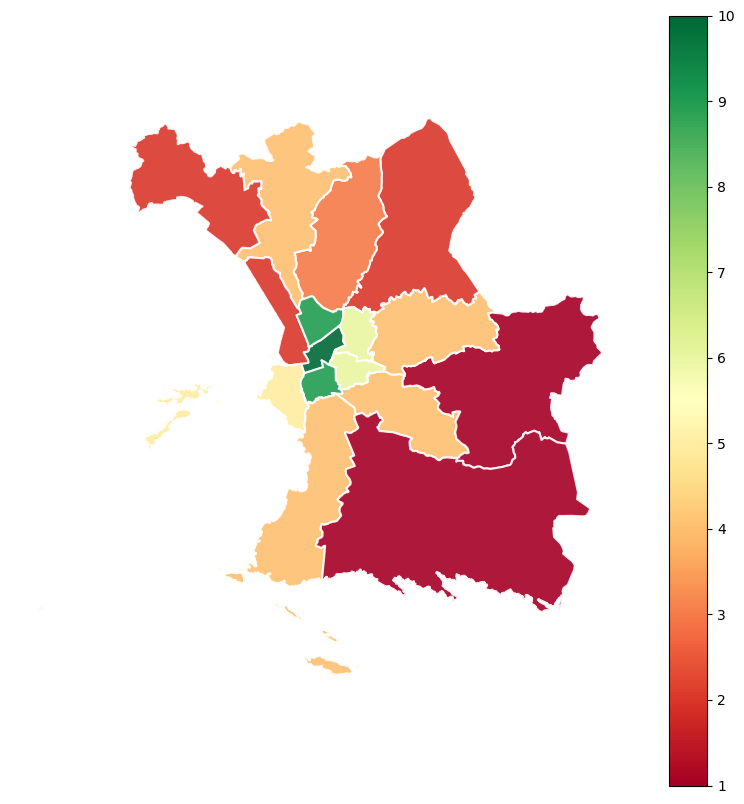

In [21]:
# --- Choropleth map of the Unified Index across all 16 districts ------------
# Red = low quality of life, Green = high quality of life (RdYlGn color ramp)

f, ax = plt.subplots(1,1, figsize=(10,10))

gdf_index.plot(ax=ax, edgecolor='w', linewidth=1.5, alpha=0.9, column='Unified Index', cmap='RdYlGn', legend=True)

ax.axis('off');

In [ ]:
# =============================================================================
# BONUS — ACCESSIBILITY INDEX by H3 hexagonal grid cells 
# =============================================================================

"""

Computes an Urban Accessibility Index for Marseille, France, combining some previous indicators 
- healthcare, recreation, public transports, parks, emergency services, commerce, employment centers - 
at H3 hexagonal grid cells scale (resolution 9, ~105 m edge length)

"""

In [23]:
# H3 requires WGS84 (EPSG:4326) coordinates — reproject before polyfilling.
gdf_index = gdf_index.to_crs(4326)

In [24]:
# .polyfill() fills each district polygon with H3 cell indices
# explode=True creates one row per H3 cell
resolution = 9 # Adjust resolution as needed
gdf_h3 = gdf_index.h3.polyfill(resolution, explode=True)

In [25]:
gdf_h3 = gdf_h3[gdf_h3['h3_polyfill'].isnull() == False].set_index('h3_polyfill')
gdf_h3.index.name = None # Clean up the index name for readability

In [26]:
# Convert H3 cell indices to actual hexagonal boundary geometries
gdf_h3 = gdf_h3.h3.h3_to_geo_boundary()

In [27]:
# Reproject to Lambert-93 for metric spatial analysis
gdf_h3_proj = gdf_h3.to_crs(2154)

In [28]:
# Unlike the district analysis (simple intersection), the hex-level analysis
# uses circular buffers centered on each cell to capture nearby features:
#   - 1600 m ≈ 20-min walk / 5-min bike: suitable for schools, transit, cycle paths
#   - 800 m  ≈ 10-min walk: suitable for parks (shorter acceptable distance)

def analyze_access(hex_geometry):
    """
    Measure accessibility indicators for a single H3 hexagon using spatial buffers.
    
    """
    buffer_1600m = hex_geometry.buffer(1600) # ~20-min walk radius
    buffer_800m = hex_geometry.buffer(800) # ~10-min walk radius

    # Count features within buffers
    num_healthcare = healthcare[healthcare.geometry.intersects(buffer_1600m)].shape[0]
    num_recreation = recreation[recreation.geometry.intersects(buffer_1600m)].shape[0]
    num_public_transport = public_transport[public_transport.geometry.intersects(buffer_800m)].shape[0]
    park_area = parks[parks.geometry.intersects(buffer_800m)].area.sum()
    num_emergency_services = emergency_services[emergency_services.geometry.intersects(buffer_1600m)].shape[0]
    num_commerce = commerce[commerce.geometry.intersects(buffer_1600m)].shape[0]
    num_employment_centers = employment_centers[employment_centers.geometry.intersects(buffer_1600m)].shape[0]
    

    return num_healthcare, num_recreation, num_public_transport, park_area, num_emergency_services, num_commerce, num_employment_centers

In [29]:
# Concatenate all district's indicators into a single GeoDataFrame (one GeoDataFrame by indicator)

districts = [f for f in os.listdir('data') if '.' not in f]

healthcare_list = []
recreation_list = []
public_transport_list = []
parks_list = []
emergency_services_list = []
commerce_list = []
employment_centers_list = []


for district in districts :
    healthcare_geojson = gpd.read_file('data/'+ district + '/healthcare.geojson')
    recreation_geojson = gpd.read_file('data/'+ district + '/recreation.geojson')
    public_transport_geojson = gpd.read_file('data/'+ district + '/public_transport.geojson')
    parks_geojson = gpd.read_file('data/'+ district + '/parks.geojson')
    emergency_services_geojson = gpd.read_file('data/'+ district + '/emergency_services.geojson')
    commerce_geojson = gpd.read_file('data/'+ district + '/commerce.geojson')
    employment_centers_geojson = gpd.read_file('data/'+ district + '/employment_centers.geojson')
    healthcare_list.append(healthcare_geojson)
    recreation_list.append(recreation_geojson)
    public_transport_list.append(public_transport_geojson)
    parks_list.append(parks_geojson)
    emergency_services_list.append(emergency_services_geojson)
    commerce_list.append(commerce_geojson)
    employment_centers_list.append(employment_centers_geojson)

healthcare = pd.concat(healthcare_list)
recreation = pd.concat(recreation_list)
public_transport = pd.concat(public_transport_list)
parks = pd.concat(parks_list)
emergency_services = pd.concat(emergency_services_list)
commerce = pd.concat(commerce_list)
employment_centers = pd.concat(employment_centers_list)

In [ ]:
# Reprojection of all data in Lambert93 (for length or area measurements)
healthcare = healthcare.to_crs(2154)
recreation = recreation.to_crs(2154)
public_transport = public_transport.to_crs(2154)
parks = parks.to_crs(2154)
emergency_services = emergency_services.to_crs(2154)
commerce = commerce.to_crs(2154)
employment_centers = employment_centers.to_crs(2154)

In [31]:
# Apply analysis to each hex cell
gdf_h3_proj[['num_healthcare', 'num_recreation', 'num_public_transport', 'park_area', 'num_emergency_services', 'num_commerce', 'num_employment_centers']] = gdf_h3_proj.geometry.apply(
    lambda hex_geom: pd.Series(analyze_access(hex_geom))
)

In [32]:
gdf_h3_proj['h3_index'] = gdf_h3_proj.index

In [ ]:
# Normalize results
# Ensures all indicators are on the same scale before aggregation.
scaler = MinMaxScaler()
normalized_columns = ['num_healthcare', 'num_recreation', 'num_public_transport', 'park_area', 'num_emergency_services', 'num_commerce', 'num_employment_centers']
gdf_h3_proj[normalized_columns] = scaler.fit_transform(gdf_h3_proj[normalized_columns])

# Aggregate results using neighboring cells
def aggregate_neighbors(h3_index):
    """
    Smooth a hex cell's indicator values by averaging over its 2-ring neighborhood.
    h3.grid_disk(index, k) returns all H3 cells within k rings of the given cell,
    including the cell itself (total up to 1 + 6 + 12 = 19 cells for k=2).
 
    Returns
    -------
    pd.Series : mean indicator values across the neighborhood
    """
    neighbors = h3.grid_disk(h3_index, 2)  # 2-k ring
    neighbor_values = gdf_h3_proj[gdf_h3_proj['h3_index'].isin(neighbors)][normalized_columns].mean()
    return neighbor_values

# Apply neighbor-based spatial smoothing to all hex cells
gdf_h3_proj[normalized_columns] = gdf_h3_proj['h3_index'].apply(
    lambda h3_index: aggregate_neighbors(h3_index)
)

# Final normalized analysis
gdf_h3_proj[normalized_columns] = scaler.fit_transform(gdf_h3_proj[normalized_columns])

In [ ]:
# Creation of a composite score
gdf_h3_proj['index_score'] = gdf_h3_proj['num_healthcare'] + gdf_h3_proj['num_recreation'] + gdf_h3_proj['num_public_transport'] + gdf_h3_proj['park_area'] + gdf_h3_proj['num_emergency_services'] + gdf_h3_proj['num_commerce'] + gdf_h3_proj['num_employment_centers'] 

In [ ]:
#Vizualisation in Leafmap

m = leafmap.Map()
m.add_data(
    gdf_h3_proj, column="index_score", scheme="Quantiles", cmap="RdYlGn", legend_title="Index"
)
m